In [1]:
import cv2
from gymnasium import Env
from gymnasium.spaces import Box, Discrete
import matplotlib.pyplot as plt
from mss import mss
import numpy as np
import pyautogui
import pytesseract
import time

### Build the Environment

In [ ]:
class WebGame(Env):
    def __init__(self):
        super().__init__()
        self.observation_space = Box(low=0, high=255, shape=(1, 83, 100), dtype=np.uint8)
        self.action_space = Discrete(3)
        self.cap = mss()
        # 400% zoom; 1440p monitor
        self.game_location = {'top': 200, 'left': 150, 'width': 600, 'height': 500}
        self.done_location = {'top': 250, 'left': 920, 'width': 800, 'height': 70}
    
    def get_observation(self):
        raw = np.array(self.cap.grab(self.game_location))[:, :, :3].astype(np.uint8)
        gray = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, (100, 83))
        channel = np.reshape(resized, (1, 83, 100))

        return channel

    def get_done(self):
        done_cap = np.array(self.cap.grab(self.done_location))
        done_strings = ['GAME', 'GAHE']
        done = False
        res = pytesseract.image_to_string(done_cap)[:4]

        if res in done_strings:
            done = True
        
        return done, done_cap

    def step(self, action):
        action_map = {0: 'space', 1: 'down', 2: 'no_op'}

        if action != 2:
            pyautogui.press(action_map[action])
        
        done, done_cap = self.get_done()
        observation = self.get_observation()
        reward = 1
        info = {}

        return observation, reward, done, info
    
    def render(self):
        cv2.imshow('Game', self.current_frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            self.close()
    
    def reset(self):
        time.sleep(1)
        pyautogui.click(x=150, y=150)
        pyautogui.press('space')

        return self.get_observation()

    def close(self):
        cv2.destroyAllWindows()

In [88]:
env = WebGame()
obs=env.get_observation()

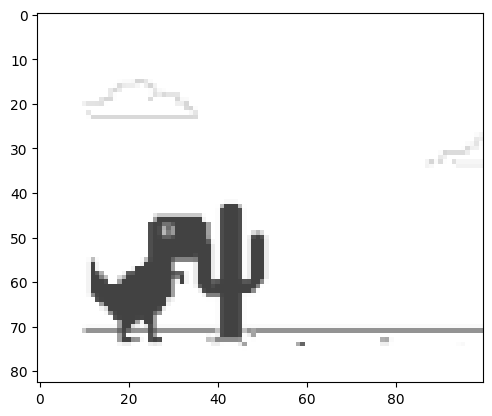

In [89]:
plt.imshow(cv2.cvtColor(obs[0], cv2.COLOR_GRAY2BGR))

'GAME'

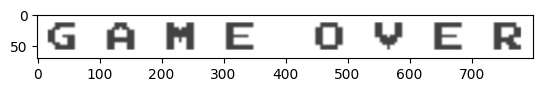

In [90]:
done, done_cap = env.get_done()
plt.imshow(done_cap)
pytesseract.image_to_string(done_cap)[:4]

In [ ]:
# Test environment
# Go to chrome://dino
env = WebGame()

print('REWARDS')
print('--------------------')
for episode in range(10):
    obs = env.reset()
    done = False
    total_reward = 0

    while not done:
        obs, reward, done, info = env.step(env.action_space.sample())
        total_reward += reward
    
    print(f"Episode {episode + 1} = {total_reward}")

REWARDS
--------------------
Episode 1 = 59
Episode 2 = 21
Episode 3 = 62
Episode 4 = 26
Episode 5 = 19
Episode 6 = 24
Episode 7 = 23
Episode 8 = 22
Episode 9 = 23
Episode 10 = 68


: 

---
### Train the Agent

---
### Test the Agent